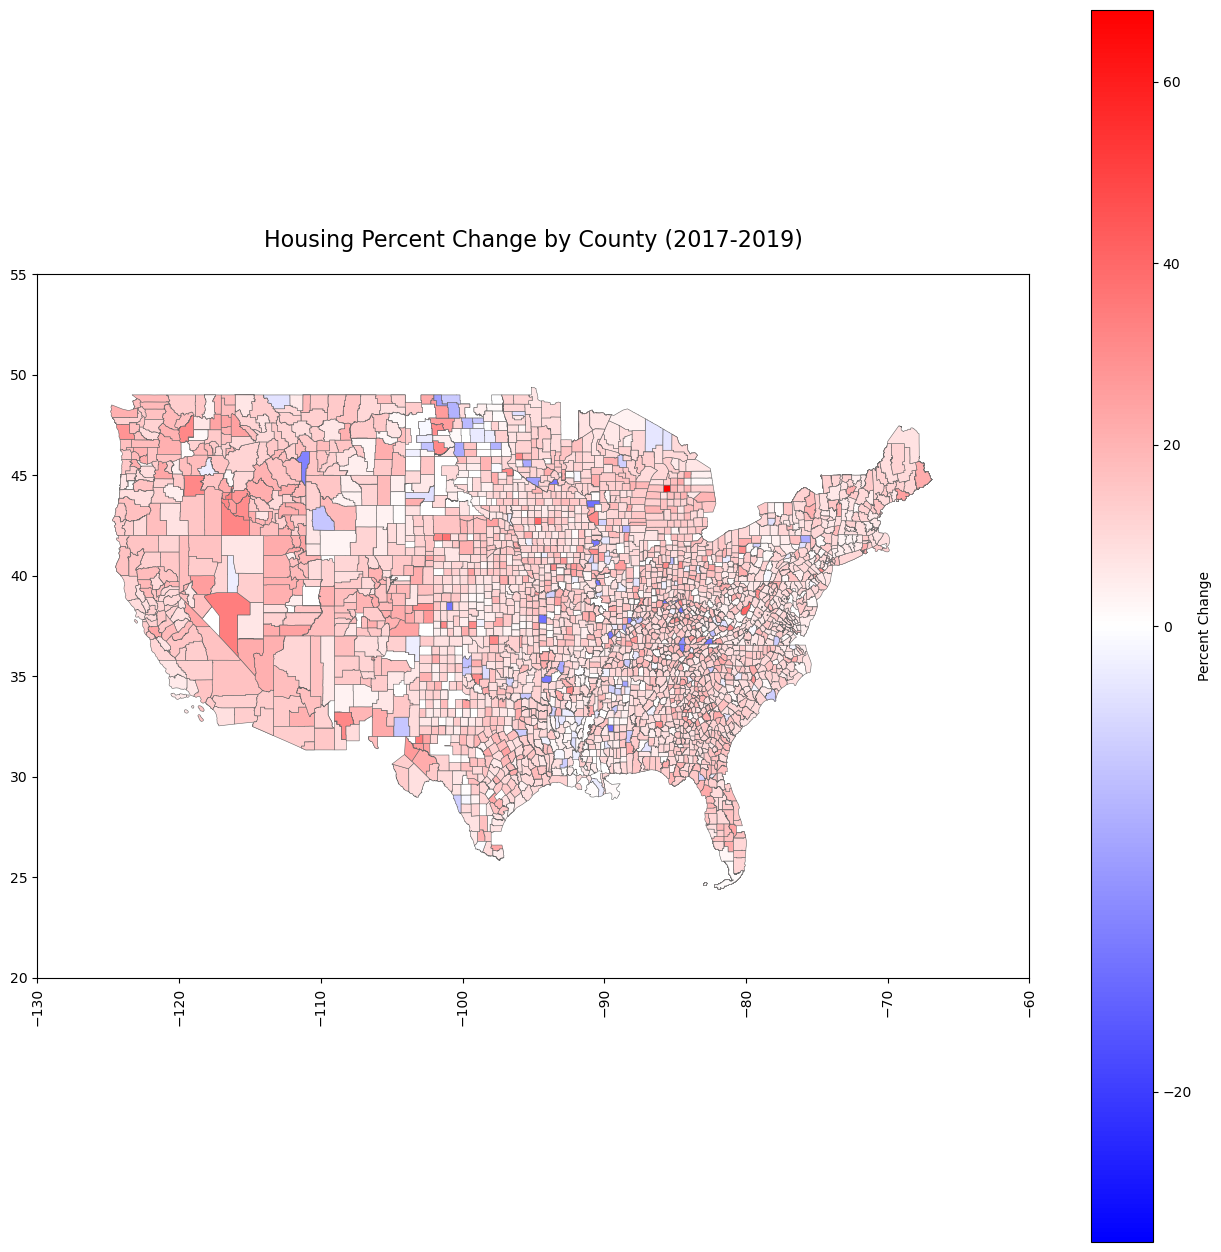

In [8]:
#!/usr/bin/env python
# coding: utf-8

import pandas as pd 
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.colors import TwoSlopeNorm
import geopandas as gpd
import os

# Read Zillow data
zillow = pd.read_csv('Data/zillow county.csv')
zillow_2017_cols = [col for col in zillow.columns if '2017' in str(col)]
zillow_2019_cols = [col for col in zillow.columns if '2019' in str(col)]

# Calculate the average of 2017 and 2019 columns for each row
zillow['zillow_2017'] = zillow[zillow_2017_cols].mean(axis=1)
zillow['zillow_2019'] = zillow[zillow_2019_cols].mean(axis=1)

# Remove date columns
date_columns = [col for col in zillow.columns if '-' in str(col)]
zillow_filtered = zillow.drop(columns=date_columns)

# Read the county shapefile
county = gpd.read_file(os.getcwd()+ '/tl_2019_us_county')
map_zillow = county.merge(zillow_filtered, left_on='NAMELSAD', right_on='RegionName')

# Calculate percent change
map_zillow['change'] = (map_zillow['zillow_2019'] - map_zillow['zillow_2017'])/map_zillow['zillow_2017'] * 100

# Set up the figure and axis
fig, ax = plt.subplots(1, figsize=(16, 16))
plt.xticks(rotation=90)

# Define normalization with the midpoint at 0
norm = TwoSlopeNorm(vmin=map_zillow["change"].min(), vcenter=0, vmax=map_zillow["change"].max())

# Plot the data using the 'bwr' colormap
map_zillow.plot(column="change", 
                cmap="bwr", 
                linewidth=0.4, 
                ax=ax, 
                edgecolor=".4", 
                legend=False, 
                norm=norm)

# Set x and y limits to focus on mainland US
ax.set_xlim(-130, -60)
ax.set_ylim(20, 55)

# Create the colorbar
sm = plt.cm.ScalarMappable(cmap="bwr", norm=norm)
sm._A = []  # Empty array for the ScalarMappable
cbar = fig.colorbar(sm, ax=ax)
cbar.set_label('Percent Change')

plt.title('Housing Percent Change by County (2017-2019)', fontsize=16, pad=20)


# Create output path in Images folder
output_path = os.path.join('Images', 'Heat_Map_Zillow_PPI.png')

# Save the plot with high resolution
plt.savefig(output_path, 
            dpi=300,
            bbox_inches='tight',
            pad_inches=0.1)

plt.show()
plt.close()